Contents in Theory¶
- ADME - absorption, distribution, metabolism, and excretion

- Lead-likeness and Lipinski’s rule of five (Ro5)

- Radar charts in the context of lead-likeness


Contents in Practical¶
1. Define and visualize example molecules

2. Calculate and plot molecular properties for Ro5

3. Investigate compliance with Ro5

4. Apply Ro5 to the EGFR dataset

5. Visualize Ro5 properties (radar plot)


In a virtual screening, we aim to predict whether a compound might bind to and interact with a specific target. However, if we want to identify a new drug, it is also important that this compound reaches the target and is eventually removed from the body in a favorable way. Therefore, we should also consider whether a compound is actually taken up into the body and whether it is able to cross certain barriers in order to reach its target. Is it metabolically stable and how will it be excreted once it is not acting at the target anymore? These processes are investigated in the field of pharmacokinetics. In contrast to pharmacodynamics (“What does the drug do to our body?”), pharmacokinetics deals with the question “What happens to the drug in our body?”.


## ADME
**Absorption**: The amount and the time of drug-uptake into the body depends on multiple factors which can vary between individuals and their conditions as well as on the properties of the substance. Factors such as (poor) compound solubility, gastric emptying time, intestinal transit time, chemical (in-)stability in the stomach, and (in-)ability to permeate the intestinal wall can all influence the extent to which a drug is absorbed after e.g. oral administration, inhalation, or contact to skin.

**Distribution**: The distribution of an absorbed substance, i.e. within the body, between blood and different tissues, and crossing the blood-brain barrier are affected by regional blood flow rates, molecular size and polarity of the compound, and binding to serum proteins and transporter enzymes. Critical effects in toxicology can be the accumulation of highly apolar substances in fatty tissue, or crossing of the blood-brain barrier.

**Metabolism**: After entering the body, the compound will be metabolized. This means that only part of this compound will actually reach its target. Mainly liver and kidney enzymes are responsible for the break-down of xenobiotics (substances that are extrinsic to the body).

**Excretion**: Compounds and their metabolites need to be removed from the body via excretion, usually through the kidneys (urine) or in the feces. Incomplete excretion can result in accumulation of foreign substances or adverse interference with normal metabolism.


![alt text](image.png)

## Lead-likeness and Ro5
Lead compounds: Developmental drug candidates with promising properties; of import is bioactivity (compound binds to target of interest) and favourable ADME properties.
Ro5 states that poor absorption or permeation of a compound is more probable if the chemical structure violates more than one of the following rules:

- Molecular weight (MWT) <= 500 Da
- Number of hydrogen bond acceptors (HBAs) <= 10
- Number of hydrogen bond donors (HBD) <= 5
- Calculated LogP (octanol-water coefficient) <= 5
Note: All numbers in the Ro5 are multiples of five; this is the origin of the rule’s name.

LogP (partition coefficient or octanol-water coefficient) measures distribution of a compound, usually between a hydrophobic (e.g. 1-octanol) and a hydrophilic (e.g. water) phase.

Hydrophobic molecules might have a reduced solubility in water, while more hydrophilic molecules (e.g. high number of hydrogen bond acceptors and donors) or large molecules (high molecular weight) might have more difficulties in passing phospholipid membranes.

In [3]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw, PandasTools

In [5]:
DATA_DIR = Path("/Users/duncanfreeman/dev/bioinfo/data")

In [6]:
# Visualize example molecules:
smiles = [
    "CCC1C(=O)N(CC(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(C(=O)NC(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N(C(C(=O)N1)C(C(C)CC=CC)O)C)C(C)C)C)CC(C)C)C)CC(C)C)C)C)C)CC(C)C)C)C(C)C)CC(C)C)C)C",
    "CN1CCN(CC1)C2=C3C=CC=CC3=NC4=C(N2)C=C(C=C4)C",
    "CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC=CC=C(C)C=CC=C(C)C=CC2=C(CCCC2(C)C)C)C)C",
    "CCCCCC1=CC(=C(C(=C1)O)C2C=C(CCC2C(=C)C)C)O",
]
names = ["cyclosporine", "clozapine", "beta-carotene", "cannabidiol"]

,name,smiles,ROMol
0,cyclosporine,CCC1C(=O)N(CC(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(...,
1,clozapine,CN1CCN(CC1)C2=C3C=CC=CC3=NC4=C(N2)C=C(C=C4)C,
2,beta-carotene,CC1=C(C(CCC1)(C)C)C=CC(=CC=CC(=CC=CC=C(C)C=CC=...,
3,cannabidiol,CCCCCC1=CC(=C(C(=C1)O)C2C=C(CCC2C(=C)C)C)O,

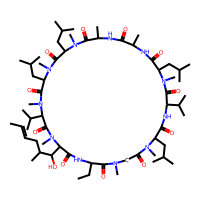
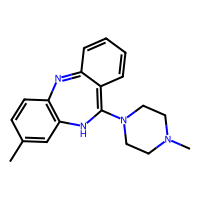
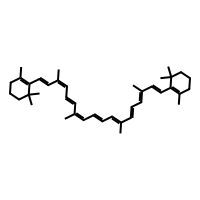
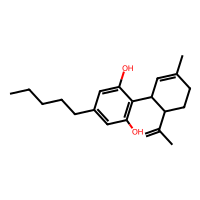

In [7]:
molecules = pd.DataFrame({"name": names, "smiles": smiles})
PandasTools.AddMoleculeColumnToFrame(molecules, "smiles")
molecules

In [8]:
molecules["molecular_weight"] = molecules["ROMol"].apply(Descriptors.ExactMolWt)
molecules["n_hba"] = molecules["ROMol"].apply(Descriptors.NumHAcceptors)
molecules["n_hbd"] = molecules["ROMol"].apply(Descriptors.NumHDonors)
molecules["logp"] = molecules["ROMol"].apply(Descriptors.MolLogP)
# Colors are used for plotting the molecules later
molecules["color"] = ["red", "green", "blue", "cyan"]
# NBVAL_CHECK_OUTPUT
molecules[["molecular_weight", "n_hba", "n_hbd", "logp"]]

,molecular_weight,n_hba,n_hbd,logp
0,1201.841368,12,5,3.26900
1,306.184447,4,1,1.68492
2,536.438202,0,0,12.60580
3,314.224580,2,2,5.84650


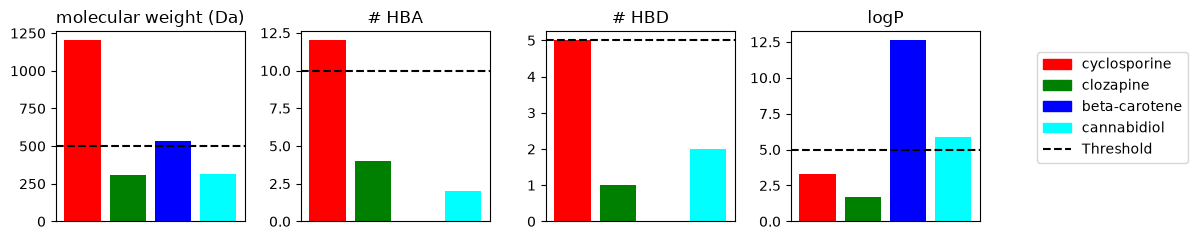

In [9]:
# Plot molecules as bar plots
ro5_properties = {
    "molecular_weight": (500, "molecular weight (Da)"),
    "n_hba": (10, "# HBA"),
    "n_hbd": (5, "# HBD"),
    "logp": (5, "logP"),
}

# Start 1x4 plot frame
fig, axes = plt.subplots(figsize=(10, 2.5), nrows=1, ncols=4)
x = np.arange(1, len(molecules) + 1)
colors = ["red", "green", "blue", "cyan"]

# Create subplots
for index, (key, (threshold, title)) in enumerate(ro5_properties.items()):
    axes[index].bar([1, 2, 3, 4], molecules[key], color=colors)
    axes[index].axhline(y=threshold, color="black", linestyle="dashed")
    axes[index].set_title(title)
    axes[index].set_xticks([])

# Add legend
legend_elements = [
    mpatches.Patch(color=row["color"], label=row["name"]) for index, row in molecules.iterrows()
]
legend_elements.append(Line2D([0], [0], color="black", ls="dashed", label="Threshold"))
fig.legend(handles=legend_elements, bbox_to_anchor=(1.2, 0.8))

# Fit subplots and legend into figure
plt.tight_layout()
plt.show()

In [10]:
def calculate_ro5_properties(smiles):
    """
    Test if input molecule (SMILES) fulfills Lipinski's rule of five.

    Parameters
    ----------
    smiles : str
        SMILES for a molecule.

    Returns
    -------
    pandas.Series
        Molecular weight, number of hydrogen bond acceptors/donor and logP value
        and Lipinski's rule of five compliance for input molecule.
    """
    # Get RDKit molecule from SMILES
    molecule = Chem.MolFromSmiles(smiles)

    # Calculate Ro5-relevant chemical properties
    molecular_weight = Descriptors.ExactMolWt(molecule)
    n_hba = Descriptors.NumHAcceptors(molecule)
    n_hbd = Descriptors.NumHDonors(molecule)
    logp = Descriptors.MolLogP(molecule)
    
    # Check if Ro5 conditions fulfilled
    conditions = [molecular_weight <= 500, n_hba <= 10, n_hbd <= 5, logp <= 5]
    ro5_fulfilled = sum(conditions) >= 3
    # Return True if no more than one out of four conditions is violated
    return pd.Series(
        [molecular_weight, n_hba, n_hbd, logp, ro5_fulfilled],
        index=["molecular_weight", "n_hba", "n_hbd", "logp", "ro5_fulfilled"],
    )

In [11]:
molecules.head(2)

,name,smiles,ROMol,molecular_weight,n_hba,n_hbd,logp,color
0,cyclosporine,CCC1C(=O)N(CC(=O)N(C(C(=O)NC(C(=O)N(C(C(=O)NC(...,<rdkit.Chem.rdchem.Mol object at 0x114d43e60>,1201.841368,12,5,3.26900,red
1,clozapine,CN1CCN(CC1)C2=C3C=CC=CC3=NC4=C(N2)C=C(C=C4)C,<rdkit.Chem.rdchem.Mol object at 0x114d43ed0>,306.184447,4,1,1.68492,green


In [13]:
# NBVAL_CHECK_OUTPUT
for name, smiles in zip(molecules["name"], molecules["smiles"]):
    print(f"Ro5 fulfilled for {name}: {calculate_ro5_properties(smiles)['ro5_fulfilled']}")

Ro5 fulfilled for cyclosporine: False
Ro5 fulfilled for clozapine: True
Ro5 fulfilled for beta-carotene: False
Ro5 fulfilled for cannabidiol: True


According to the Ro5, cyclosporin and betacarotene are estimated to have poor bioavailability. 
However, since all of them are approved drugs, they are good examples of how the Ro5 can be used as an alert but should not necessarily be used as a filter.

In [34]:
def get_lipinski_descriptors(smiles, verbose=False) -> dict:
    """
    Calculate Lipinski's Rule of Five descriptors for a given SMILES string.
    Parameters:
        smiles (str): The SMILES string of the molecule.
        verbose (bool): Whether to print verbose output.

    Returns:
        dict: A dictionary containing the calculated descriptors.
    """
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        if verbose:
            print(f"Invalid SMILES: {smiles}")
        return None
    return {
        "MW": Descriptors.MolWt(mol),                                   # Molecular Weight
        "LogP": Descriptors.MolLogP(mol),                               # Lipophilicity - the logarithm of the partition coefficient
        "NumHDonors": Descriptors.NumHDonors(mol),                      # Number of hydrogen bond donors
        "NumHAcceptors": Descriptors.NumHAcceptors(mol),                # Number of hydrogen bond acceptors
        "TPSA": Descriptors.TPSA(mol),                                  # Topological Polar Surface Area
        "RotatableBonds": Descriptors.NumRotatableBonds(mol)            # Number of rotatable bonds
    }

In [35]:
molecules_df = pd.read_csv(DATA_DIR / "EGFR_compounds_downloaded.csv")
print(f"Shape: {molecules_df.shape}")

Shape: (5568, 6)


In [36]:
# Drop rows where IC50 values are missing , zero, or negative
molecules_df = molecules_df.dropna(subset=['IC50'])
molecules_df = molecules_df[molecules_df['IC50'] > 0]
molecules_df.shape

(5568, 6)

In [37]:
# Apply Ro5 to all molecules in the dataframe and add results as new columns
#ro5_properties = molecules_df["smiles"].apply(get_lipinski_descriptors)
#ro5_properties.head(2)
# Create a dataframe of Lipinski descriptors from canonical_smiles values
df_lipinski = molecules_df.apply(lambda row: get_lipinski_descriptors(row['smiles']), axis=1)
print(df_lipinski)


0       {'MW': 350.21900000000005, 'LogP': 5.289100000...
1       {'MW': 388.26500000000016, 'LogP': 4.933300000...
2       {'MW': 344.216, 'LogP': 3.5969000000000015, 'N...
3       {'MW': 340.184, 'LogP': 4.012200000000001, 'Nu...
4       {'MW': 330.189, 'LogP': 3.572600000000002, 'Nu...
                              ...                        
5563    {'MW': 164.16, 'LogP': 1.49, 'NumHDonors': 2, ...
5564    {'MW': 404.8360000000001, 'LogP': 5.2004800000...
5565    {'MW': 172.187, 'LogP': 1.5980599999999998, 'N...
5566    {'MW': 450.39600000000013, 'LogP': -0.41620000...
5567    {'MW': 274.272, 'LogP': 2.324500000000001, 'Nu...
Length: 5568, dtype: object


In [38]:
df_lipinski = pd.DataFrame(df_lipinski.to_list())
df_lipinski.head(2)

,MW,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds
0,350.219,5.2891,1,3,37.81,2
1,388.265,4.9333,1,5,56.27,6


In [39]:
molecules_df = pd.concat([molecules_df, df_lipinski], axis=1)
molecules_df.head()

,Unnamed: 0,molecule_chembl_id,IC50,units,smiles,pIC50,MW,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds
0,0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,350.219,5.2891,1,3,37.81,2
1,1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,388.265,4.9333,1,5,56.27,6
2,2,CHEMBL53711,0.006,nM,CN(C)c1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.221849,344.216,3.5969,1,5,53.94,3
3,3,CHEMBL66031,0.008,nM,Brc1cccc(Nc2ncnc3cc4[nH]cnc4cc23)c1,11.096910,340.184,4.0122,2,4,66.49,2
4,4,CHEMBL53753,0.008,nM,CNc1cc2c(Nc3cccc(Br)c3)ncnc2cn1,11.096910,330.189,3.5726,2,5,62.73,3


In [40]:
def convert_ic50_to_pic50(df: pd.DataFrame, ic50_col: str = 'standard_value', pic50_col: str = 'pIC50') -> pd.DataFrame:
    """
    Convert IC50 values to pIC50 values.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    ic50_col (str): The column name for the IC50 values.
    pic50_col (str): The column name for the pIC50 values.

    Returns:
    pd.DataFrame: The DataFrame with the pIC50 column added.

    Constraints: IC50 values must be positive numbers.
    """
    ic50 = pd.to_numeric(df[ic50_col], errors='coerce')
    # Standardise the standard_value such that vals > 100,000,000 are replaced with 100,000,000
    ic50.clip(lower=None, upper=1e8, inplace=True)
    df[pic50_col] = -np.log10(ic50 * 1e-9)
    return df

In [41]:
molecules_df = molecules_df.rename(columns={'pIC50': 'pIC50_old'})

In [42]:
molecules_df = convert_ic50_to_pic50(molecules_df, ic50_col='IC50', pic50_col='pIC50')

In [43]:
# create a column to indicate if a molecule follows the Ro5, returning True if no more than one out of four conditions is violated, else False
ro5_conditions = [
    molecules_df['MW'] <= 500,
    molecules_df['NumHAcceptors'] <= 10,
    molecules_df['NumHDonors'] <= 5,
    molecules_df['LogP'] <= 5
]
molecules_df['Ro5_fulfilled'] = sum(~condition for condition in ro5_conditions) <= 1


In [44]:
molecules_df.head(2)

,Unnamed: 0,molecule_chembl_id,IC50,units,smiles,pIC50_old,MW,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,pIC50,Ro5_fulfilled
0,0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,350.219,5.2891,1,3,37.81,2,11.522879,True
1,1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,388.265,4.9333,1,5,56.27,6,11.221849,True


In [45]:
molecules_df['Ro5_fulfilled'].value_counts()

Ro5_fulfilled
True     4661
False     907
Name: count, dtype: int64

In [46]:

molecules_ro5_fulfilled = molecules_df[molecules_df["Ro5_fulfilled"]]
molecules_ro5_violated = molecules_df[~molecules_df["Ro5_fulfilled"]]

print(f"# compounds in unfiltered data set: {molecules_df.shape[0]}")
print(f"# compounds in filtered data set: {molecules_ro5_fulfilled.shape[0]}")
print(f"# compounds not compliant with the Ro5: {molecules_ro5_violated.shape[0]}")
# NBVAL_CHECK_OUTPUT

# compounds in unfiltered data set: 5568
# compounds in filtered data set: 4661
# compounds not compliant with the Ro5: 907


In [48]:
# Save data with compounds containing Ro5 fulfilled to a separate CSV file
molecules_ro5_fulfilled.to_csv(DATA_DIR / "EGFR_molecules_ro5_fulfilled.csv", index=False)

## Visualize Ro5 properties (radar plot)¶
1. Calculate statistics on Ro5 properties¶
2. Define a helper function to calculate the mean and standard deviation for an input DataFrame.
3. Calculate the statistic for the dataset of compounds that are fulfilling the Ro5.

In [49]:
def calculate_mean_std(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate the mean and standard deviation of a dataset.

    Parameters
    ----------
    df : pd.DataFrame
        Properties (columns) for a set of items (rows).

    Returns
    -------
    pd.DataFrame
        Mean and standard deviation (columns) for different properties (rows).
    """
    # Generate descriptive statistics for property columns
    stats = df.describe()
    # Transpose DataFrame (statistical measures = columns)
    stats = stats.T
    # Select mean and standard deviation
    stats = stats[["mean", "std"]]
    return stats

In [50]:
molecules_ro5_fulfilled.columns

Index(['Unnamed: 0', 'molecule_chembl_id', 'IC50', 'units', 'smiles',
       'pIC50_old', 'MW', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA',
       'RotatableBonds', 'pIC50', 'Ro5_fulfilled'],
      dtype='str')

In [ ]:
# Calculate mean and standard deviation for the selected columns
molecules_ro5_fulfilled_stats = calculate_mean_std(
    molecules_ro5_fulfilled[["MW", "NumHAcceptors", "NumHDonors", "LogP"]]
)
molecules_ro5_fulfilled_stats

,mean,std
MW,415.992271,88.764561
NumHAcceptors,5.747265,1.766904
NumHDonors,1.892298,1.006410
LogP,4.066507,1.192322


In [64]:
molecules_ro5_violated_stats = calculate_mean_std(
    molecules_ro5_violated[["MW", "NumHAcceptors", "NumHDonors", "LogP"]]
)
molecules_ro5_violated_stats

,mean,std
MW,589.127222,103.310054
NumHAcceptors,7.571114,2.338412
NumHDonors,2.300992,1.743113
LogP,6.048878,1.372639


In [53]:
# 2. Define helper functions to prep for radar plotting.
#Prepare y values: The properties used for the Ro5 criteria are of different magnitudes;
# The MWT has a threshold of 500, whereas the number of HBAs and HBDs and the LogP have thresholds of only 10, 5, and 5, respectively. 
# In order to visualize these different scales most simplistically, we will scale all property values to a scaled threshold of 5:
# scaled property value = property value / property threshold * scaled property threshold
# scaled MWT = MWT / 500 * 5 
# scaled HBA = HBA / 10 * 5 
# scaled HBD = HBD / 5 * 5 
# scaled LogP = LogP / 5 * 5

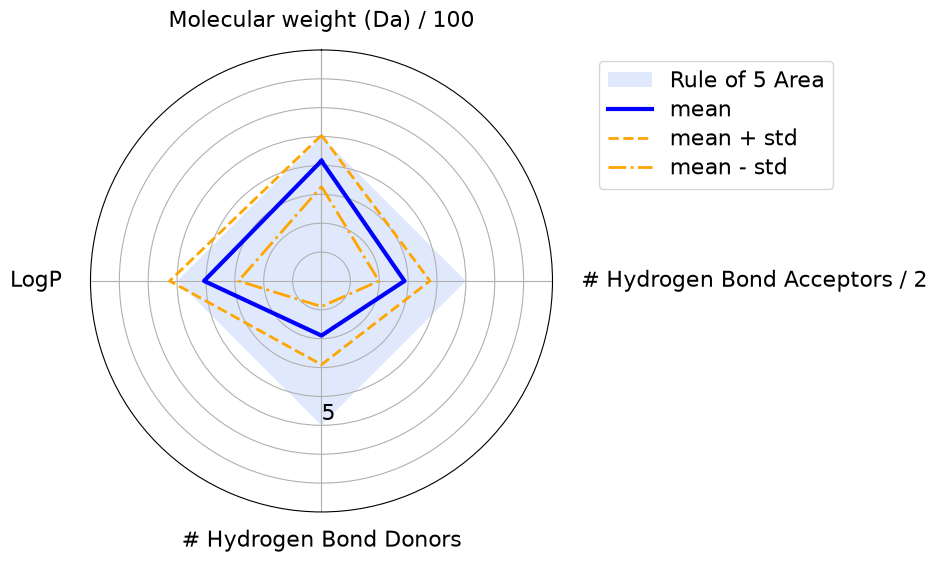

In [67]:
def _scale_by_thresholds(stats, thresholds, scaled_threshold):
    """
    Scale values for different properties that have each an individually defined threshold.

    Parameters
    ----------
    stats : pd.DataFrame
        Dataframe with "mean" and "std" (columns) for each physicochemical property (rows).
    thresholds : dict of str: int
        Thresholds defined for each property.
    scaled_threshold : int or float
        Scaled thresholds across all properties.

    Returns
    -------
    pd.DataFrame
        DataFrame with scaled means and standard deviations for each physiochemical property.
    """
    # Raise error if scaling keys and data_stats indicies are not matching
    for property_name in stats.index:
        if property_name not in thresholds.keys():
            raise KeyError(f"Add property '{property_name}' to scaling variable.")
    # Scale property data
    stats_scaled = stats.apply(lambda x: x / thresholds[x.name] * scaled_threshold, axis=1)
    return stats_scaled

def _define_radial_axes_angles(n_axes):
    """Define angles (radians) for radial (x-)axes depending on the number of axes."""
    x_angles = [i / float(n_axes) * 2 * math.pi for i in range(n_axes)]
    x_angles += x_angles[:1]
    return x_angles

def plot_radar(
    y,
    thresholds,
    scaled_threshold,
    properties_labels,
    y_max=None,
    output_path=None,
):
    """
    Plot a radar chart based on the mean and standard deviation of a data set's properties.

    Parameters
    ----------
    y : pd.DataFrame
        Dataframe with "mean" and "std" (columns) for each physicochemical property (rows).
    thresholds : dict of str: int
        Thresholds defined for each property.
    scaled_threshold : int or float
        Scaled thresholds across all properties.
    properties_labels : list of str
        List of property names to be used as labels in the plot.
    y_max : None or int or float
        Set maximum y value. If None, let matplotlib decide.
    output_path : None or pathlib.Path
        If not None, save plot to file.
    """

    # Define radial x-axes angles -- uses our helper function!
    x = _define_radial_axes_angles(len(y))
    # Scale y-axis values with respect to a defined threshold -- uses our helper function!
    y = _scale_by_thresholds(y, thresholds, scaled_threshold)
    # Since our chart will be circular we append the first value of each property to the end
    y = pd.concat([y, y.head(1)])

    # Set figure and subplot axis
    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)

    # Plot data
    ax.fill(x, [scaled_threshold] * len(x), "cornflowerblue", alpha=0.2)
    ax.plot(x, y["mean"], "b", lw=3, ls="-")
    ax.plot(x, y["mean"] + y["std"], "orange", lw=2, ls="--")
    ax.plot(x, y["mean"] - y["std"], "orange", lw=2, ls="-.")

    # From here on, we only do plot cosmetics
    # Set 0° to 12 o'clock
    ax.set_theta_offset(math.pi / 2)
    # Set clockwise rotation
    ax.set_theta_direction(-1)

    # Set y-labels next to 180° radius axis
    ax.set_rlabel_position(180)
    # Set number of radial axes' ticks and remove labels
    plt.xticks(x, [])
    # Get maximal y-ticks value
    if not y_max:
        y_max = int(ax.get_yticks()[-1])
    # Set axes limits
    plt.ylim(0, y_max)
    # Set number and labels of y axis ticks
    plt.yticks(
        range(1, y_max),
        ["5" if i == scaled_threshold else "" for i in range(1, y_max)],
        fontsize=16,
    )

    # Draw ytick labels to make sure they fit properly
    # Note that we use [:1] to exclude the last element which equals the first element (not needed here)
    for i, (angle, label) in enumerate(zip(x[:-1], properties_labels)):
        if angle == 0:
            ha = "center"
        elif 0 < angle < math.pi:
            ha = "left"
        elif angle == math.pi:
            ha = "center"
        else:
            ha = "right"
        ax.text(
            x=angle,
            y=y_max + 1,
            s=label,
            size=16,
            horizontalalignment=ha,
            verticalalignment="center",
        )

    # Add legend relative to top-left plot
    labels = ("Rule of 5 Area", "mean", "mean + std", "mean - std")
    ax.legend(labels, loc=(1.1, 0.7), labelspacing=0.3, fontsize=16)

    # Save plot - use bbox_inches to include text boxes
    if output_path:
        plt.savefig(output_path, dpi=300, bbox_inches="tight", transparent=True)

    plt.show()

thresholds = {"MW": 500, "NumHAcceptors": 10, "NumHDonors": 5, "LogP": 5}
scaled_threshold = 5
properties_labels = [
    "Molecular weight (Da) / 100",
    "# Hydrogen Bond Acceptors / 2",
    "# Hydrogen Bond Donors",
    "LogP",
]
y_max = 8

plot_radar(
    molecules_ro5_fulfilled_stats,
    thresholds,
    scaled_threshold,
    properties_labels,
    y_max,
)

The blue square shows the area where a molecule’s physicochemical properties are compliant with the Ro5. 
The blue line highlights the mean values.
The orange dashed lines show the standard deviations. 
We can see that the mean values never violate any of Lipinski’s rules. However, according to the standard deviation, some properties have larger values then the Ro5 thresholds. This is acceptable because, according to the Ro5, one of the four rules can be violated.

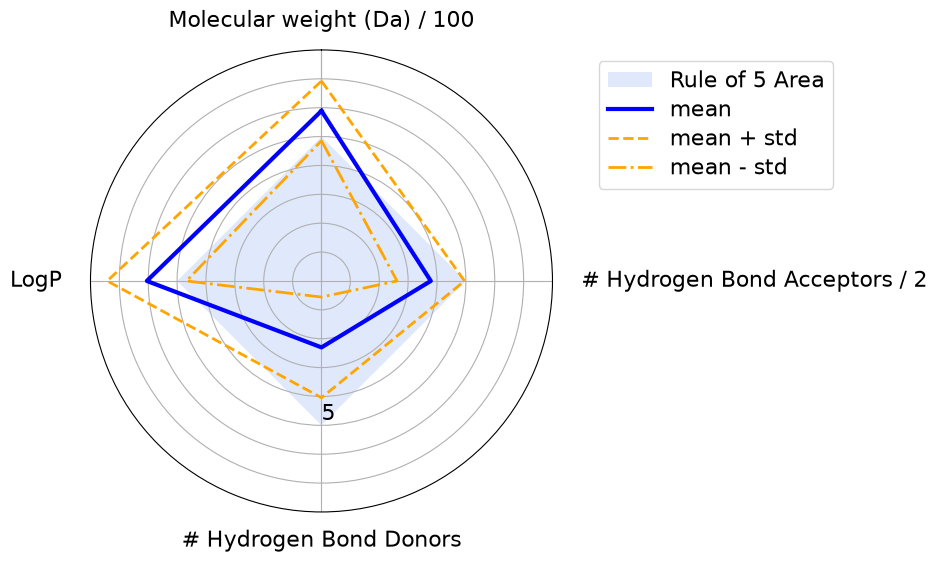

In [68]:
plot_radar(
    molecules_ro5_violated_stats,
    thresholds,
    scaled_threshold,
    properties_labels,
    y_max,
)

We see that compounds mostly violate the Ro5 because of their logP values and their molecular weight.

### Quiz
1. In what way can the chemical properties described by the Ro5 affect ADME?
2. Find or design a molecule which violates three or four rules.
- Molecular weight (MWT) <= 500 Da
- Number of hydrogen bond acceptors (HBAs) <= 10
- Number of hydrogen bond donors (HBD) <= 5
- Calculated LogP (octanol-water coefficient) <= 5

3. Plot information for an additional molecule in the radar charts.

Answers:
Q1
Absorption Membrane Permeability: High molecular weight (>500 Da) and excessive hydrogen bond donors (>5) or acceptors (>10) slow down or block passive diffusion across the non-polar lipid bilayer of the intestinal mucosa.Lipophilicity (\(\text{LogP}>5\)): Extreme fat solubility causes molecules to trap themselves inside lipid cell membranes or drop aqueous solubility, preventing proper dissolution in the gastrointestinal tract.DistributionTissue Penetration: Compounds with high lipophilicity and low polar surface area distribute rapidly into deep tissues and fat stores, but values violating Ro5 thresholds often suffer from high plasma protein binding, lowering the free active drug concentration in systemic circulation.Blood-Brain Barrier (BBB): Strict limits on hydrogen bond donors and molecular size are required for a drug to cross into the central nervous system passively.Metabolism and ExcretionClearance Rates: While the core Ro5 metrics primarily target the "A" in ADME (absorption and permeation), excessive lipophilicity heavily increases recognition and processing by hepatic cytochrome P450 enzymes and vulnerability to active efflux pumps (like P-glycoprotein), accelerating clearance and shortening half-life.

Q2 --> code cell


In [69]:
# Answers: Q2
molecules_df.head(2)

,Unnamed: 0,molecule_chembl_id,IC50,units,smiles,pIC50_old,MW,LogP,NumHDonors,NumHAcceptors,TPSA,RotatableBonds,pIC50,Ro5_fulfilled
0,0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,350.219,5.2891,1,3,37.81,2,11.522879,True
1,1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,388.265,4.9333,1,5,56.27,6,11.221849,True


In [ ]:
# create a column to indicate if a molecule follows the Ro5, returning True if no more than one out of four conditions is violated, else False
ro5_conditions = [
    molecules_df['MW'] <= 500,
    molecules_df['NumHAcceptors'] <= 10,
    molecules_df['NumHDonors'] <= 5,
    molecules_df['LogP'] <= 5
]
molecules_df['Ro5_fulfilled'] = sum(~condition for condition in ro5_conditions) <= 1